<a href="https://colab.research.google.com/github/prajwalbiradar21/Insurance_Premium_cost_prediction_using_ML-Model/blob/main/Insurance_Cost_Prediction_using_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Health Insurance Price Prediction

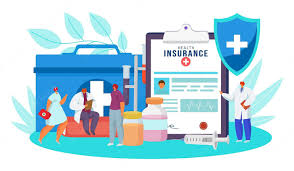

### Problem Statement

Insurance companies often struggle to set accurate premium prices for customers.
Premiums depend on several factors such as age, gender, BMI, number of children, smoking habits, and region.
However, manual or traditional methods of pricing are not only time-consuming but can also lead to inaccuracies.

The goal of this project is to build a machine learning model that can predict the medical insurance premium amount based on a person's demographic and lifestyle attributes.

### Objective :

To predict the medical insurance premium amount based on customer demographics and lifestyle factors (like age, BMI, smoking habits, region, etc.).

#### Data Description :

The dataset contains demographic information about insured individuals along with their medical costs.

The Dataset contains **1,338 Records** and is sourced from [Kaggle](https://www.kaggle.com/code/taghreedaburwished/insurance-cost-prediction-using-machine-learning).


It includes **7 Features** , which provide demographic, lifestyle and health_related Infromation :

**Features**

| Column       | Description                                     | Type        |
| ------------ | ----------------------------------------------- | ----------- |
| **age**      | Age of the person                               | Numeric     |
| **sex**      | Gender (male/female)                            | Categorical |
| **bmi**      | Body Mass Index                                 | Numeric     |
| **children** | Number of children/dependents                   | Numeric     |
| **smoker**   | Smoking habit (yes/no)                          | Categorical |
| **region**   | Residential region (northeast, northwest, etc.) | Categorical |
| **charges**  | Insurance premium (Target Variable)             | Numeric     |



* This dataset is suitable for building a **supervised regression model** , as  the goal is to predict the continous variable **ie.- charges.(This is the Target Variable)**




### Importing Basic Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')



### Load Dataset

In [ ]:
data=pd.read_csv('/content/drive/MyDrive/Machine Learning projects for learning/Insurance premium Price Prediction model /insurance.csv')

pd.set_option('display.max_columns',None) # display all columns
pd.set_option('display.max_rows',100)

In [ ]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### Understanding the Variables


  Dataset Variables Explanation

 1. **age**
    - **Description:** Age of the insured person
    - **Type:** Numeric (continuous)
   - **Impact:** Older people usually have higher health risks, so insurance charges increase with age.

 2. **sex**
    - **Description:** Gender of the insured person (male/female)
    - **Type:** Categorical
    - **Impact:** Gender generally has less influence on premium cost compared to other variables.

 3. **bmi**
    - **Description:** Body Mass Index (BMI) — measure of body fat based on height and weight
    - **Type:** Numeric (continuous)
    - **Impact:** Higher BMI indicates overweight/obesity, leading to higher health risk and increased premiums.

 4. **children**
    - **Description:** Number of children/dependents covered by the insurance
    - **Type:** Numeric (discrete)
    - **Impact:** More dependents can slightly increase charges, as more people are being insured.

 5. **smoker**
    - **Description:** Whether the person is a smoker (yes/no)
    - **Type:** Categorical (binary)
    - **Impact:** One of the most influential factors — smokers usually have much higher medical costs, so premiums increase significantly.

 6. **region**
    - **Description:** The region where the insured person lives (northeast, northwest, southeast, southwest)
    - **Type:** Categorical (nominal)
    - **Impact:** Reflects geographical differences in healthcare costs; usually minor impact compared to age, BMI, or smoking.

 7. **charges**
    - **Description:** Individual medical insurance cost billed by health insurance
    - **Type:** Numeric (continuous) **-->(This The Target Variable)**
    - **Impact:** This is the target variable (the one we will predict).




### Basic Checks Understanding of the Data .

In [ ]:
# check the number of rows and columns
print(data.shape)
print("no.of Rows:", data.shape[0]) # 0 --> rows
print("no. of Columns:", data.shape[1]) # 1 --> columns

(1338, 7)
no.of Rows: 1338
no. of Columns: 7


In [ ]:
# to print all columns name
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
# check first 5 rows
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# check last 5 rows
data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [ ]:
# check the datatype of each columns

data.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
# check the dataset info

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
# check for numerical columns
num_col = data.select_dtypes(include=['int64','float64'])
num_col.head(3)

,age,bmi,children,charges
0,19,27.90,0,16884.9240
1,18,33.77,1,1725.5523
2,28,33.00,3,4449.4620


In [ ]:
# check for categorical columns
cat_col = data.select_dtypes(include=['object'])
cat_col.head()

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest


In [ ]:
# check for unique values
data.nunique()

,0
age,47
sex,2
bmi,548
children,6
smoker,2
region,4
charges,1337


In [ ]:
# checking for unique values in categorical columns
for x in cat_col.columns:
  print(f'{x}  : {data[x].unique()}')
# print()

sex  : ['female' 'male']
smoker  : ['yes' 'no']
region  : ['southwest' 'southeast' 'northwest' 'northeast']


In [ ]:
# check for unique values in numerical np.column_stack
for y in num_col.columns:
  print(y, data[y].unique())

age [19 18 28 33 32 31 46 37 60 25 62 23 56 27 52 30 34 59 63 55 22 26 35 24
 41 38 36 21 48 40 58 53 43 64 20 61 44 57 29 45 54 49 47 51 42 50 39]
bmi [27.9   33.77  33.    22.705 28.88  25.74  33.44  27.74  29.83  25.84
 26.22  26.29  34.4   39.82  42.13  24.6   30.78  23.845 40.3   35.3
 36.005 32.4   34.1   31.92  28.025 27.72  23.085 32.775 17.385 36.3
 35.6   26.315 28.6   28.31  36.4   20.425 32.965 20.8   36.67  39.9
 26.6   36.63  21.78  30.8   37.05  37.3   38.665 34.77  24.53  35.2
 35.625 33.63  28.    34.43  28.69  36.955 31.825 31.68  22.88  37.335
 27.36  33.66  24.7   25.935 22.42  28.9   39.1   36.19  23.98  24.75
 28.5   28.1   32.01  27.4   34.01  29.59  35.53  39.805 26.885 38.285
 37.62  41.23  34.8   22.895 31.16  27.2   26.98  39.49  24.795 31.3
 38.28  19.95  19.3   31.6   25.46  30.115 29.92  27.5   28.4   30.875
 27.94  35.09  29.7   35.72  32.205 28.595 49.06  27.17  23.37  37.1
 23.75  28.975 31.35  33.915 28.785 28.3   37.4   17.765 34.7   26.505
 22.04  35

In [ ]:
# find value counts
for x in cat_col.columns:
  print(x, data[x].value_counts())

sex sex
male      676
female    662
Name: count, dtype: int64
smoker smoker
no     1064
yes     274
Name: count, dtype: int64
region region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [ ]:
# performing statistical analysis on numerical colums
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
# performing statistical analysis on categorical columns
data.describe(include=['object'])

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [ ]:
# check for any missing values
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
# check for duplicates in the dataset
data.duplicated().sum()

np.int64(1)

###  Insights
### What did you know about your dataset?

Basic Information about the Dataset

The dataset contains information about individuals' demographic and health attributes
along with their medical insurance charges.

* **Total Rows and Columns:** The dataset has **1338 rows** and **7 columns.**

*  **Columns Overview:**
1. age       → Numeric (int)         → Age of the person
2. sex       → Categorical (object)  → Gender (male/female)
3. bmi       → Numeric (float)       → Body Mass Index
4. children  → Numeric (int)         → Number of children/dependents
5. smoker    → Categorical (object)  → Whether the person is a smoker (yes/no)
6. region    → Categorical (object)  → Residential region (northeast, northwest, southeast, southwest)
7. charges   → Numeric (float)       → Insurance charges (target variable)

* **Categorical Columns:** ['sex', 'smoker', 'region']

* **Numerical Columns:** ['age', 'bmi', 'children', 'charges']

* **Missing Values:** There are no missing values in this dataset.

* **Duplicates:** There is only one duplicate rows in the dataset.

* **Target Variable:** **('charges)** — this represents the medical insurance cost billed by the insurance company.


### Data Cleaning and Preprocessing

### Missing values:

**Missing Values**
these are blank or null entries in the dataset .

**Why it matters:** Missing data can lead to inaccurate analysis or biased results.

**Common Fixes :**
* Remove rows with missing data(if few).
* (Or) Fill with avg() , medians() or most frequent values.

 **-- Numerical data is missing replace with --**
* **Mean() :** when data has normal distribution . -- (Mean() - avg of the data)
* **Median() :** when data is Skewed . -- (median() - is the middle value of the data)

**-- When Categorical data is missing --**
* **Mode() :** most frequently occuring data . --(mode() - most occured data in the dataset.)

In [ ]:
# check for missing values in the dataset

data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
# no missing values in this Dataset.


### Duplicate values

Duplicate data means repeated Rows or Records -- when the same onfo appears more than once.

**Why it matters :**
* Duplicates can distort totals,averages or ther calculations.
* Identify and remove them to keep only unique records.

In [ ]:
# find duplicates
data.duplicated().sum()

np.int64(1)

In [ ]:
# remove duplicates   #inplace=True will permemently drop that row
data.drop_duplicates(inplace = True)

In [ ]:
data.duplicated().sum()

np.int64(0)

### Handling outliers

**Outliers** are the values that are much higher or lower than the rest of the data , unusual data points in the dataset.

* Outliers might be mostly in the numerical columns.

**Why Handle Outliers?**
* they can mess up the average
* thet an confuse machine learning models
* model might learn wrong patterns,etc

**How to fing direction of Outliers?**
* Box Plot
* Histrogram

## Box Plot

In [ ]:
num_col.columns

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

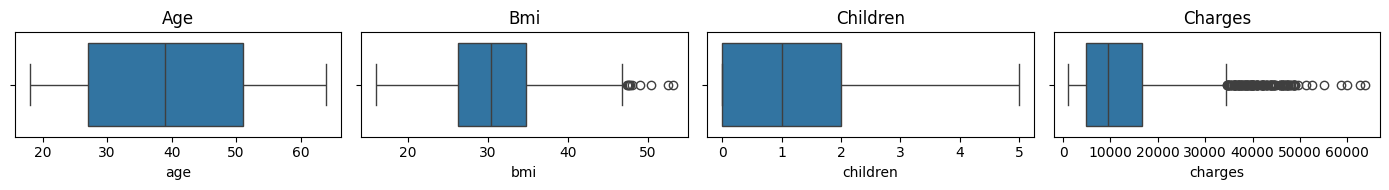

In [ ]:
fig , axes=plt.subplots(1,4,figsize=(14,2))

for i,col in enumerate(num_col.columns):
  sns.boxplot(data = data , x = col , ax = axes[i])
  axes[i].set_title(col.capitalize())
  plt.tight_layout()

**Insights :** There are outliers in the columns of 'bmi' & 'charges' towards right side

## Histrogram

In [ ]:
num_col.columns

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

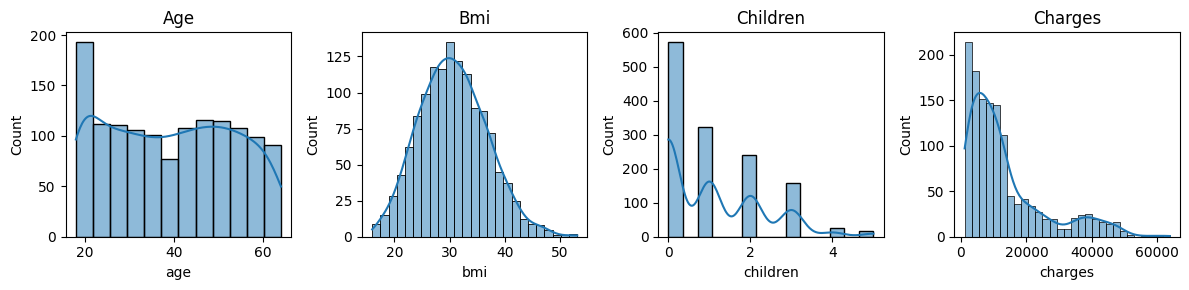

In [ ]:
fig , axes=plt.subplots(1,4,figsize=(12,3))

for i,col in enumerate(num_col.columns):
  sns.histplot(data = data , x = col , ax = axes[i],kde=True)
  axes[i].set_title(col.capitalize())
  plt.tight_layout()

**Insight -**

**BMI:** it represents Normal Distribution.

**Charges:** it represents right skewed distribution.

### Handling Outliers :

 How to Handle Outliers?
* check the **distribution of the data**.
* If the data is **normal dist.** use **3sigma rule**.
* If data is **skewed dist.** use **IQR Method** .

###  **1) 3 Sigma Rule :**

In Normal Distribution :

* 68% of data lies within **±1σ (1 std deviation from the Mean)**
* 95% of the data lies within **±2σ **
* 99.7% of the data lies within **±3σ**

So, any data points outside **±3σ is considered as an outlier.**





* μ = Mean

* σ = standard deviation

Then:

* **Lower Bound = μ - 3σ**
* **Upper Bound = μ + 3σ**

Any data point outside this range is flagged as an **Outlier**.



In [ ]:
# as BMI data distribution is normal -- we will use 3sigma rule

#lower limit -- (mean -3*std) , Upper limit -- (mean+ 3*std)

lower_limit = data.loc[: ,'bmi'].mean() - 3 * data.loc[: ,'bmi'].std()
print(f'Lower Bound - {lower_limit}')

upper_limit = data.loc[: ,'bmi'].mean() + 3 * data.loc[: ,'bmi'].std()
print(f'Upper Bound - {upper_limit}')

# print('lower',lower_limit , 'upper',upper_limit)

Lower Bound - 12.362046528819015
Upper Bound - 48.96485698651382


In [ ]:
# filter data which is greater than upper  and less than lower
data.loc[data.loc[ : ,'bmi']> upper_limit]

,age,sex,bmi,children,smoker,region,charges
116,58,male,49.06,0,no,southeast,11381.3254
847,23,male,50.38,1,no,southeast,2438.0552
1047,22,male,52.58,1,yes,southeast,44501.3982
1317,18,male,53.13,0,no,southeast,1163.4627


In [ ]:
data.loc[data.loc[ : ,'bmi']< lower_limit]

,age,sex,bmi,children,smoker,region,charges


In [ ]:
# using both the condition in one line
data.loc[(data.loc[ : ,'bmi']> upper_limit) | (data.loc[ : ,'bmi']< lower_limit)]

,age,sex,bmi,children,smoker,region,charges
116,58,male,49.06,0,no,southeast,11381.3254
847,23,male,50.38,1,no,southeast,2438.0552
1047,22,male,52.58,1,yes,southeast,44501.3982
1317,18,male,53.13,0,no,southeast,1163.4627


In [ ]:
#find the % of outliers
# if % of outliers are less than 5% then we can perform some operation or else we should not touch them

len(data.loc[(data.loc[ : ,'bmi']> upper_limit) | (data.loc[ : ,'bmi']< lower_limit)]) *100 / len(data)

0.2991772625280479

In [ ]:
# if the % of outliers is less than 5% , then only replace or  drop then ; otherwise dont touch them


# replacing them with mean()

data.loc[(data.loc[ : ,'bmi']> upper_limit) | (data.loc[ : ,'bmi']< lower_limit),'bmi']=data.loc[ : , 'bmi'].mean()

In [ ]:
# now check if there are any outliers -- therefore, they are replaced with the mean() value

data.loc[(data.loc[ : ,'bmi']> upper_limit) | (data.loc[ : ,'bmi']< lower_limit)]

,age,sex,bmi,children,smoker,region,charges


### **IQR Method :**

IQR(InterQuartile Range) is a measure of spread in the middle 50% of the data.

In Skewed Distribution:

It is calculated as:

**IQR = Q3 -Q1**

where:
*  **Q1(25th percentile)** = value below which 25% of the data falls .

*  **Q3(75th percentile)** = value below which 75% of the data falls .


**How to Use IQR to Detect Outliers:**

We define outliers as value that falls:

*  Below:

Lower Bound : **Q1 - 1.5 * IQR**

Above:

*  Upper Bound : **Q3 + 1.5 * IQR**

Any data points **outside this range** is considered as an Outliers.

In [ ]:
#column 'charges' has distribution of right skewed so we use IQR method.

Q1 = data.loc[ : , 'charges'].quantile(0.25)
Q3 = data.loc[ : , 'charges'].quantile(0.75)

IQR = Q3-Q1

print(f'Q1 : {Q1} , Q3 : {Q3} , IQR : {IQR}')

Q1 : 4746.344 , Q3 : 16657.71745 , IQR : 11911.37345


In [ ]:
# find lower limit

lower_limit_iqr = Q1 - 1.5 * IQR
print(lower_limit_iqr)

-13120.716174999998


In [ ]:
# find upper limit
upper_limit_iqr = Q3 + 1.5 * IQR
print(upper_limit_iqr)

34524.777625


In [ ]:
#filter data which is less than lower limit
data.loc[data.loc[ : ,'charges'] < lower_limit_iqr]

,age,sex,bmi,children,smoker,region,charges


In [ ]:
#filter data which is greater than upper limit
data.loc[data.loc[ : ,'charges'] > upper_limit_iqr]

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,62592.87309
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1313,19,female,34.700,2,yes,southwest,36397.57600


In [ ]:
# combining both the conditions

data.loc[(data.loc[ : ,'charges'] > upper_limit_iqr) | (data.loc[ : ,'charges'] < lower_limit_iqr)  ]

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,62592.87309
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1313,19,female,34.700,2,yes,southwest,36397.57600


In [ ]:
# lets find the percentage of the outliers

len(data.loc[(data.loc[ : ,'charges'] > upper_limit_iqr) | (data.loc[ : ,'charges'] < lower_limit_iqr)  ]) / len(data) *100

10.396409872849663

In [ ]:
#since the % of the outlier is more than 5% , therefore lets not touch that

### Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the first step in analyzing data. It involves exploring the dataset to understand its structure and patterns, and to clean the data for further analysis. Here's a simpler breakdown:

## **What EDA Does:**
*  **Summarize Data:** Get basic statistics like average, maximum, and minimum values to understand the data better.

*  **Visualize Data:** Create charts like histograms, box plots, and scatter plots to see distributions and relationships between variables.

*  **Find Outliers:** Identify any unusual or incorrect data points that don’t fit with the rest.

*  **Understand Patterns:** Look for trends, correlations, and insights to guide further analysis or decision-making.

*  **Clean Data:** Handle missing data, remove or fill in duplicates, and fix any incorrect data.

## **Key Tools Used in EDA:**


*  **Descriptive Statistics:** Mean, median, standard deviation.

*  **Visuals:** Histograms (for distribution), boxplots (for spread and outliers), scatter plots (for relationships).

* **Data Cleaning:**

   *  **Duplicates:** Identify and remove duplicate rows.
   *  **Missing Values:** Handle missing values by removing or imputing them.


## Why EDA is Important:

*  **Clean the Data:** Spot and fix missing or incorrect values. Handle duplicates to ensure accuracy.

*  **Make Decisions:** Helps you decide how to proceed with more advanced analysis or build predictive models.

In short, **EDA is about understanding the data** before you dive into deeper analysis or modeling. It also ensures your data is clean and ready for further work.

#### **Univariate**






Univariate analysis examines one variable at a time to understand its distribution, central tendency, and spread. It answers questions like:

*  What does the data look like?

*  How is it distributed?

*  Are there any outliers or dominant categories?

| Graph Type | Description | Type of Data |
|-------------|-------------|---------------|
| **Histogram** | Shows the frequency distribution of continuous (numeric) data by dividing it into intervals (bins). | Continuous / Numeric |
| **Count Plot** | Displays counts of categories using bars — helps visualize how often each category appears. | Categorical |
| **Box Plot** | Summarizes data using median, quartiles, and outliers — useful for detecting spread and outliers. | Continuous / Numeric |
| **Pie Chart** | Shows proportions or percentages of categories as slices of a circle. | Categorical |

In [ ]:
# Numerical columns
num_col = ['age', 'bmi', 'children', 'charges']

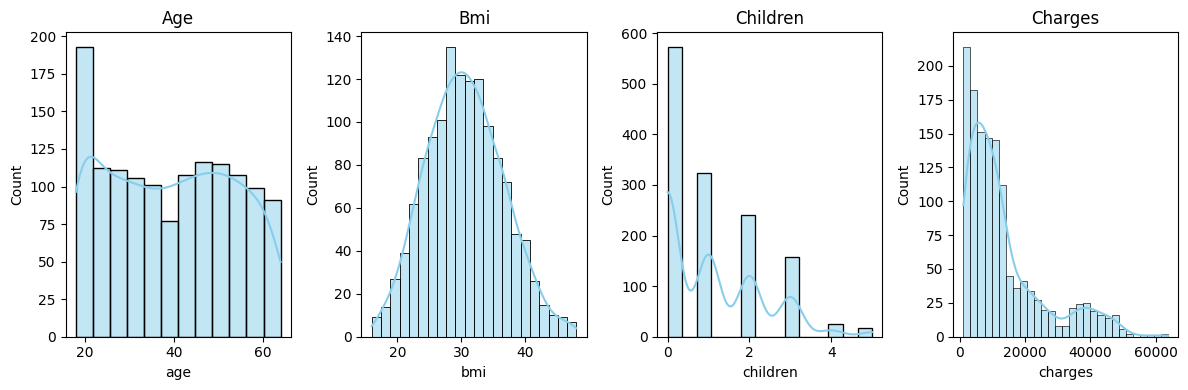

In [ ]:
# 🎯 Univariate Analysis

import matplotlib.pyplot as plt
import seaborn as sns


# Histograms for numeric columns
fig , axes = plt.subplots(1,4,figsize=(12,4))


for i,col in enumerate(num_col):

  sns.histplot(data=data , x= col , ax=axes[i],kde=True , color='skyblue')

  axes[i].set_title(col.capitalize())

plt.tight_layout()




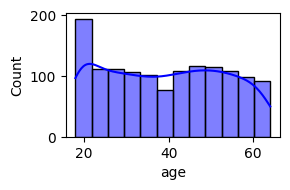

In [ ]:
# if we want single chart then:-

## Distribution of age ---

plt.figure(figsize=(3,2))
sns.histplot(data=data,x='age' ,kde=True,color='blue')
plt.tight_layout()

 **Insights :**



1.   Most of the customers age is b/w 20 to 60 years , showing that most of the customers are in the age 20 .
2.   BMI shows a normal distribution and a symmetrical about the mean.
3.   Children column has discrete values.
4.   Charges shows righr skewed distribution with most customers facing lower cost and few outliers with significant at higher charges.



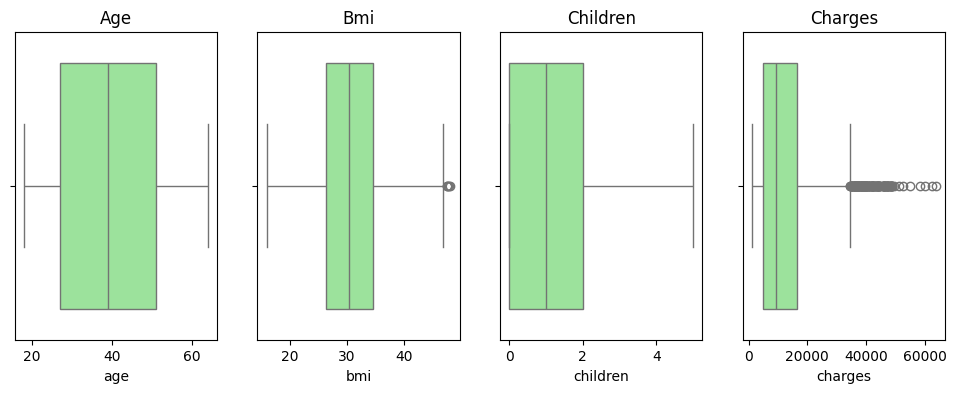

In [ ]:
# Boxplots for numeric columns (to check outliers)

fig,axes = plt.subplots(1,4,figsize=(12,4))

for i,col in enumerate(num_col):

  sns.boxplot(data=data, x=col, ax=axes[i], color='lightgreen')
  axes[i].set_title(col.capitalize())
plt.show()



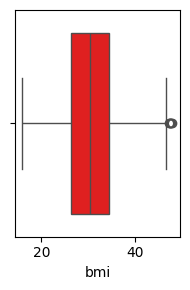

In [ ]:
# if we want single chart then:-

## Distribution of age ---

plt.figure(figsize=(2,3))
sns.boxplot(data=data,x='bmi',color='red')
plt.tight_layout()

 **Insights :**



1.   In the Age Column there are no outliers and minimum age is 20 and maximum age around 60 . Median Age is 40.
2.   In the BMI column there are few Outliers.
3.   In Charges column there are outliers but they are high charges w.r.t to certain features.   

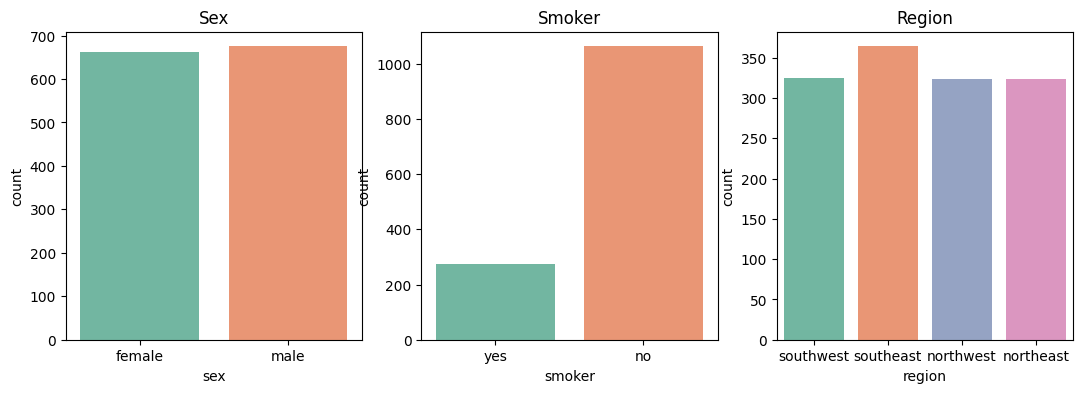

In [ ]:
# Countplots for categorical columns
cat_col = ['sex', 'smoker', 'region']

fig,axes = plt.subplots(1,3,figsize=(13,4))
for i,col in enumerate(cat_col):
  sns.countplot(data=data , x=col, ax=axes[i], palette='Set2')
  axes[i].set_title(col.capitalize())
plt.show()




**Insights :**



1.   In SEX column there are majority of Male customers compared to Female .
2.   Maximum customers are non-Smokers.
3.   Max customers are from Southeast Region and almost same in other regions.   

### **Bivariate :**



Bivariate analysis explores the relationship between two variables — it helps identify correlations, patterns, and trends. It answers questions like:

*  How are two variables related?

*  Does one variable influence the other?

*  Are there any visible patterns or trends?



| **Graph**               | **Simple Description**                                                       | **Type of Data (X vs Y)**                 |
| ----------------------- | ---------------------------------------------------------------------------- | ----------------------------------------- |
| **Line Chart**          | Shows how one variable changes with another, often over time.                | Continuous vs. Continuous                 |
| **Scatter Plot**        | Uses dots to show the relationship or pattern between two numeric variables. | Continuous vs. Continuous                 |
| **Bar Chart**           | Compares different categories with numerical values.                         | Categorical vs. Continuous                |
| **Box Plot**            | Compares the distribution of a numeric variable across different categories. | Continuous vs. Categorical                |
| **Clustered Bar Chart** | Groups bars together to compare multiple categories at once.                 | Categorical vs. Categorical vs. Numerical |


In [ ]:
# scatter plot: relationship between two numerical variables

num_col

['age', 'bmi', 'children', 'charges']

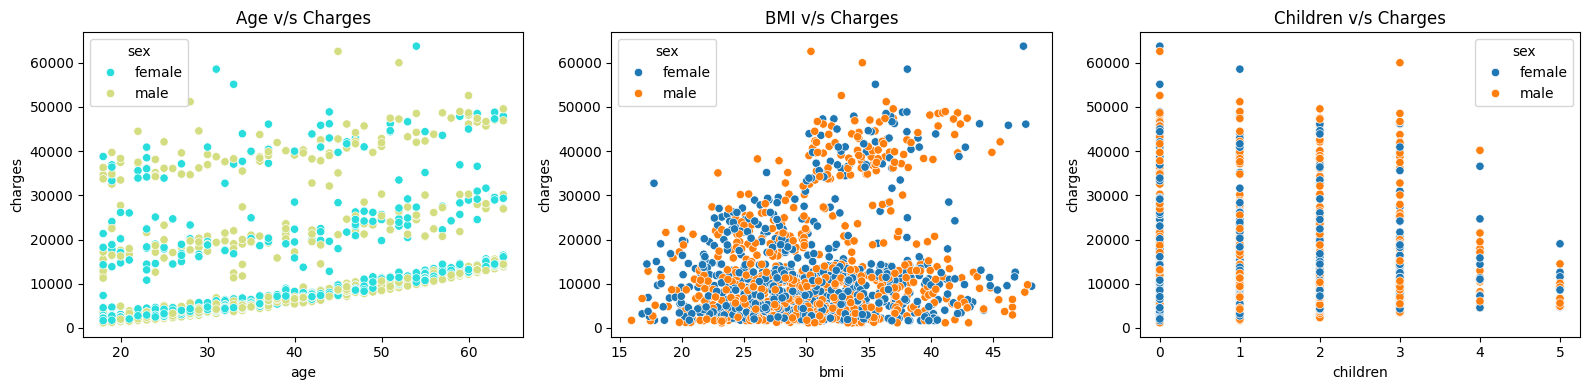

In [ ]:
fig,axes = plt.subplots(1,3,figsize=(16,4))

sns.scatterplot(data,x='age',y='charges',ax=axes[0],hue='sex',palette='rainbow')
axes[0].set_title("Age v/s Charges")

sns.scatterplot(data,x='bmi',y='charges',ax=axes[1],hue='sex')
axes[1].set_title("BMI v/s Charges")

sns.scatterplot(data,x='children',y='charges',ax=axes[2],hue='sex',color='red')
axes[2].set_title("Children v/s Charges")

plt.tight_layout()

**Insights**

1.   There is strong relationship between age and charges, as age increases we could see trend for higher medical charges, indicating old individuals will be paid higher healthcare cost.


2.   There is positive relationship between bmi and charges,a as bmi increases the insurance cost is also increasing.


3.  There is inverse relationship between children and charges.



In [ ]:
# Bar plot: 1 categorical column  , 1 numerical variable

print(num_col)
print('-------')
print(cat_col)

['age', 'bmi', 'children', 'charges']
-------
['sex', 'smoker', 'region']


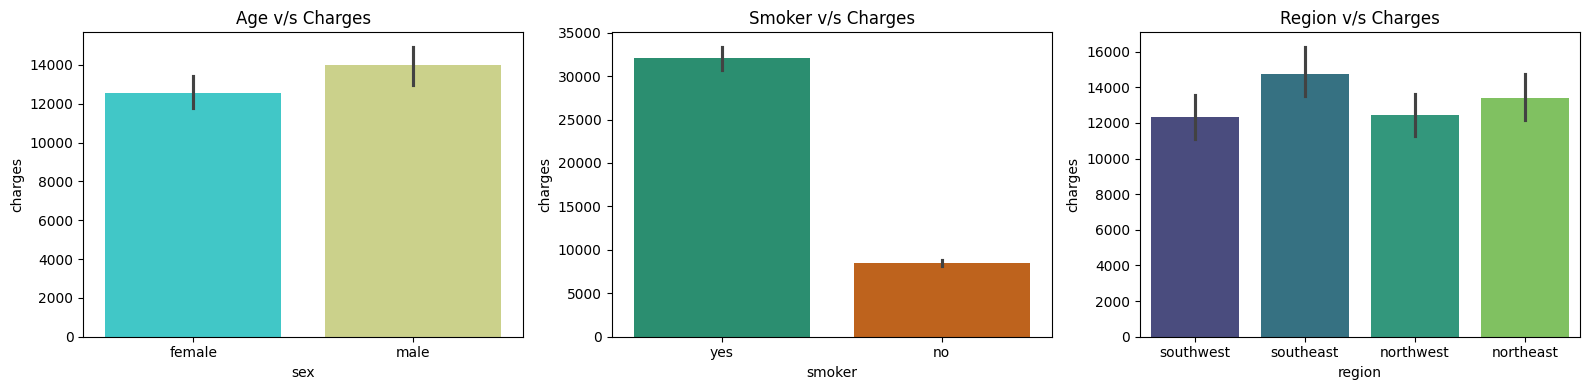

In [ ]:
fig,axes = plt.subplots(1,3,figsize=(16,4))
sns.barplot(data,x='sex',y='charges',ax=axes[0],palette='rainbow')
axes[0].set_title("Age v/s Charges")

sns.barplot(data,x='smoker',y='charges',ax=axes[1],palette='Dark2')
axes[1].set_title("Smoker v/s Charges")

sns.barplot(data,x='region',y='charges',ax=axes[2],palette='viridis')
axes[2].set_title("Region v/s Charges")

plt.tight_layout()

In [ ]:
# we can do individual charts for more insights

**Insights :**

1.   Males are getting highest medical charges comapred to female.

2.   Smokers are getting high medical charges due to increased health issues.

3.   South east people getting more insurance cost compared to other regions.






### **Multivariate**

“Multi” means many — so Multivariate analysis studies three or more variables simultaneously. It helps identify patterns, relationships, or dependencies among multiple variables.



| **Graph**     | **Simple Description**                                                                        | **Type of Data** |
| ------------- | --------------------------------------------------------------------------------------------- | ---------------- |
| **Pair Plot** | Displays scatter plots between multiple numeric variables to identify pairwise relationships. | Numeric          |
| **Heatmap**   | Uses color gradients to visualize the strength of correlation between numeric variables.      | Numeric          |


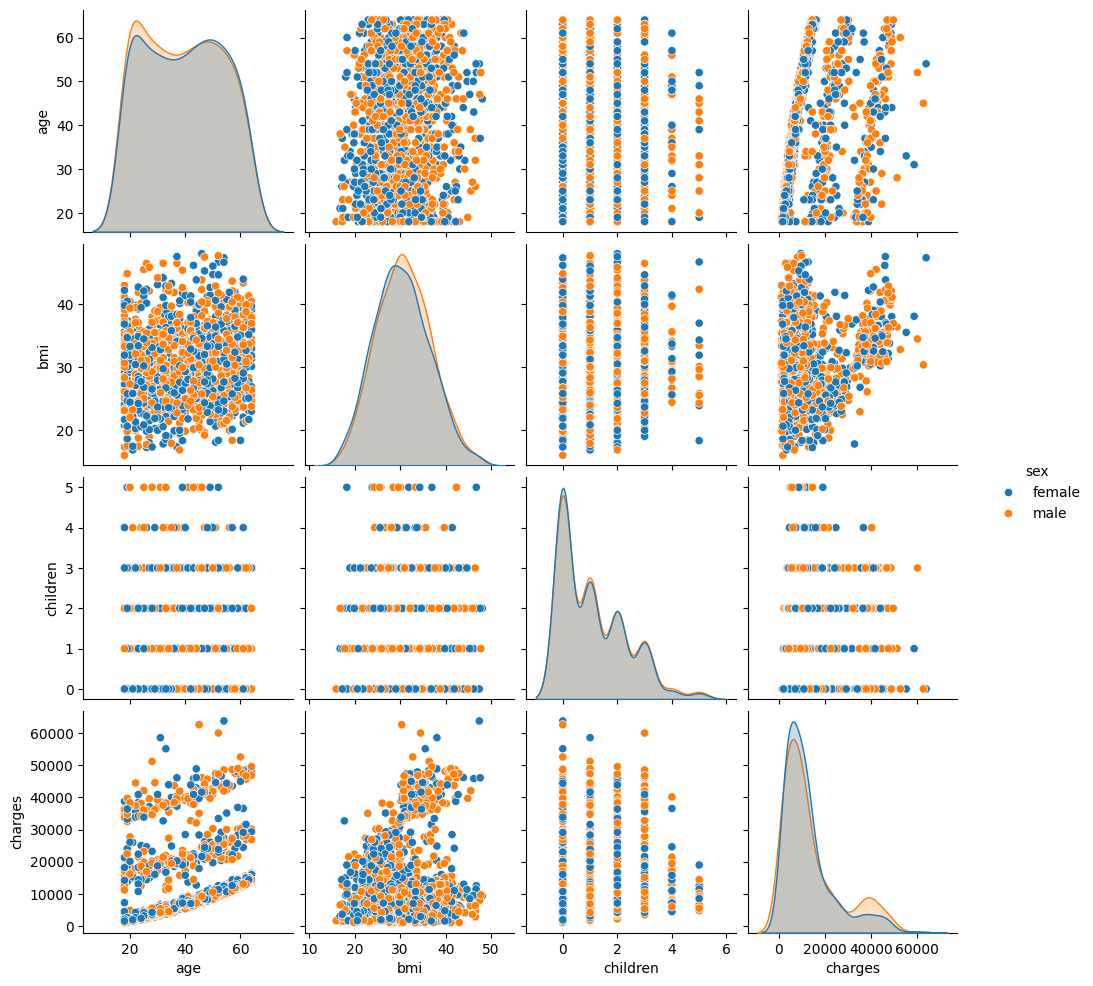

In [ ]:
# PairPlot -- hue='sex

sns.pairplot(data=data,hue= 'sex')

In [ ]:
#HeatMap _- is used to find co-relationship b/w columns

num_col.corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


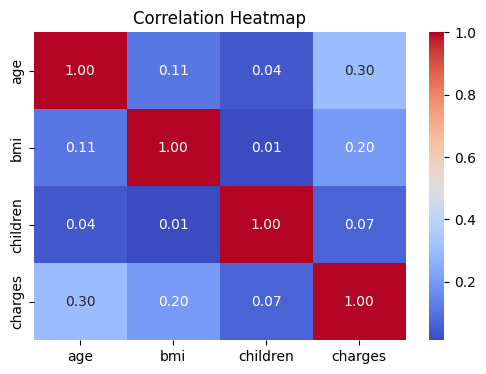

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(num_col.corr(),annot=True, cmap='coolwarm',fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

### **Insights :**




1.   **Age and charge :** Moderately positive correlation(0.3).As age increases even charges will increase.
2.   **bmi and charges :** Mild positivce correlation. As bmi increase there is a chance of increasing charges.

3.   **children and charges:** Weak correlation(0.068)

4.   **Age and bmi :** Weak correlation(0.11)



### **Feature Engineering and data transformation**

###  **Encoding**

Used to convert categorical features into a numerical format that ML models can understand.

*  **Label Encoding .**
*  **One-Hot Encoding .**
*  **Ordinal Encoding .**
*  **Target Encoding .**

### **Label Encoder :-**






LabelEncoder assigns integer labels in alpabetical order.

**Example :**

Color = ['Red' ,'Blue' , 'Green']

**LabelEncoder -->** {'Blue':0 ,'Green':1 , 'Red':2}

No Actual 'Order' in the data -- just *alphabetical indexing*.

**--- When It Fails ---- :**

For ordinal categories (where order does not matter) ,Like:

**Education** = ['UG' , 'PG' ,'PhD']

**LabelEncoder Would Give:**

LabelEncoder --> {'PG':0 ,'PhD':1 ,'UG':2}

This is Wrong , because it assigns values based on alphabetical order ,not actual logical order.

**Expected correct order should be:**

'UG' < 'PG' < 'PhD' --> {'UG' : 0 , 'PG' : 1 , 'PhD' : 2}

### **Ordinal Encoding**

Ordinal Encoding is a technique used to convert categorical features that have a meaningful order into numerical values , preserving their rank or Hierarchy.

**Example : Education Levels **

Let's say you have a column with education levels:

['UG' ,'PG' ,'PhD']

Thesse levels have a natural order : UG {UnderGraduate} < PG {PostGraduate} < PhD {Doctorate}

**Ordinal Encoding would map this as :** Eduaction Encoded Value

UG --> 0

PG --> 1

PhD --> 2

A machine learning model can now learn Patterns Like:

Higher Education Level(2 for PhD) might correlate with higher scores , income,etc.


### **One-Hot Encoding :-**

One-Hot Encoding is a technique used to convert categorical variables into a format that can be provided to machine learning algorithms.

It works by creating a new binary column for each category and placing as 1 in the column corresponding to the present category and 0 in the others.

**Goal: Convert 'City' Into Numbers**


since cities are nominal categories (no inherent order) ,we can't just assign numbers like:

Mumbai --> 0

Delhi --> 1

Banglore --> 2

This would wrongly imply that Mumbai < Delhi < Banglore ,which has no meaning.

### **Log Transformation**

### **Drop columns**

### **Feature Selection**

### **Spilt data**

### ***Scaling***

### **Split data for train and test**

# **Model Building and Evaluating**

### **Linear Regression**

### **KNN**